# 🎯 Notebook 05: Self-Attention from Scratch

## Learning Objectives

By the end of this notebook, you will:
1. Understand the intuition behind self-attention ("which words should I focus on?")
2. Implement single-head scaled dot-product attention step by step
3. Visualize attention patterns as heatmaps
4. Apply causal masking for autoregressive (decoder-only) models
5. Build a full `MultiHeadAttention` module using `mlx.nn`
6. Implement Grouped Query Attention (GQA) used in LLaMA 3 and Gemma

## Prerequisites

- **Notebook 02**: Dot products, matrix multiplication, softmax
- **Notebook 04**: Token embeddings, positional encoding
- Comfort with tensor shape manipulation

💡 **The Big Idea**: Attention lets each token in a sequence dynamically decide how much to "look at" every other token. Instead of fixed-size context windows, attention creates a learned, content-dependent mixing of information across the entire sequence.

In [1]:
from utils.checks import validate_environment, print_environment_report
validate_environment()
print_environment_report()

  Environment Validation Report
  Platform : macOS-26.4-arm64-arm-64bit-Mach-O
  Chip     : Apple M4 Pro
  Python   : 3.13.13  ✅
  MLX      : 0.31.1  ✅
  Metal GPU: available  ✅
  Memory   : 48.0 GB  ✅


{'python_version': '3.13.13',
 'python_ok': True,
 'mlx_available': True,
 'mlx_version': '0.31.1',
 'metal_available': True,
 'memory_gb': 48.0,
 'memory_ok': True,
 'chip': 'Apple M4 Pro',
 'platform': 'macOS-26.4-arm64-arm-64bit-Mach-O'}

## The Intuition: "Which Words Should I Focus On?"

Consider the sentence: **"The cat sat on the mat because it was tired"**

When processing the word **"it"**, the model needs to figure out: *what does "it" refer to?*

- A human reader knows "it" → "cat" (not "mat")
- Self-attention learns this by computing a **relevance score** between every pair of tokens
- "it" will assign a high attention weight to "cat" and low weight to "mat"

The mechanism works in three steps:

1. **Query (Q)**: "What am I looking for?" — each token asks a question
2. **Key (K)**: "What do I contain?" — each token advertises its content
3. **Value (V)**: "What information do I provide?" — each token holds information to share

> 💡 **The Library Analogy**: Think of attention like searching a library.
> - **Q** is your search query — you walk in and ask "I need information about cats."
> - **K** is the title and summary on each book's spine — each book advertises what it's about so you can decide if it's relevant.
> - **V** is the actual content inside each book — once you pick the relevant books, this is the information you take home.
>
> The dot product Q·K is like comparing your search query against every book title. High match → you pull that book off the shelf. Softmax turns these matches into a "how much to read each book" weighting. The final output is a weighted blend of all the book contents (V), with the most relevant books contributing the most.

The attention score between tokens is just a **dot product** between a query and a key:
$$\text{score}(i, j) = \mathbf{q}_i \cdot \mathbf{k}_j$$

High dot product = high relevance = "pay more attention to this token."

⚡ This is why transformers are so powerful on Apple Silicon — attention is just matrix multiplications, and the M4 Pro's GPU is optimized for exactly that.

In [2]:
import mlx.core as mx
import mlx.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import math

# We'll work with a small example throughout this notebook
# Imagine a sentence with 6 tokens, each embedded in 8 dimensions
seq_len = 6
d_model = 8
tokens = ["The", "cat", "sat", "on", "the", "mat"]

# Simulate token embeddings (in practice these come from nn.Embedding + positional encoding)
mx.random.seed(42)
x = mx.random.normal((1, seq_len, d_model))  # shape: (1, 6, 8) — (batch, seq_len, d_model)
print(f"Input x shape: {x.shape}  — (batch=1, seq_len={seq_len}, d_model={d_model})")
print(f"First token embedding (The): {x[0, 0, :4].tolist()}...")  # show first 4 dims

Input x shape: (1, 6, 8)  — (batch=1, seq_len=6, d_model=8)
First token embedding (The): [-0.19599026441574097, -0.5413612723350525, 1.708802342414856, 0.3340412974357605]...


---
## Section 1: Single-Head Attention from Scratch

### Step 1 — Create Q, K, V Projection Matrices

Each token embedding gets projected into three separate spaces using learned weight matrices:
- $W_Q \in \mathbb{R}^{d_{model} \times d_k}$ — projects to **query** space
- $W_K \in \mathbb{R}^{d_{model} \times d_k}$ — projects to **key** space
- $W_V \in \mathbb{R}^{d_{model} \times d_v}$ — projects to **value** space

For single-head attention, $d_k = d_v = d_{model}$.

💡 Why three separate projections? The same token might need to *ask* different questions (Q) than what it *advertises* (K) or what information it *provides* (V). Separating these gives the model more flexibility.

In [3]:
d_k = d_model  # For single-head: d_k = d_model = 8

# Create projection matrices (these are the learnable parameters)
W_q = mx.random.normal((d_model, d_k)) * 0.1   # shape: (8, 8)
W_k = mx.random.normal((d_model, d_k)) * 0.1   # shape: (8, 8)
W_v = mx.random.normal((d_model, d_k)) * 0.1   # shape: (8, 8)

print(f"W_q shape: {W_q.shape}  — projects d_model → d_k")
print(f"W_k shape: {W_k.shape}  — projects d_model → d_k")
print(f"W_v shape: {W_v.shape}  — projects d_model → d_v")

# Project input to Q, K, V
# x: (1, 6, 8) @ W_q: (8, 8) → Q: (1, 6, 8)
Q = x @ W_q  # shape: (1, seq_len, d_k) = (1, 6, 8)
K = x @ W_k  # shape: (1, seq_len, d_k) = (1, 6, 8)
V = x @ W_v  # shape: (1, seq_len, d_v) = (1, 6, 8)

print(f"\nQ shape: {Q.shape}  — queries for each token")
print(f"K shape: {K.shape}  — keys for each token")
print(f"V shape: {V.shape}  — values for each token")

# Verify: each row of Q is one token's query vector
print(f"\nQuery vector for 'The':  {Q[0, 0, :4].tolist()}...")
print(f"Query vector for 'cat':  {Q[0, 1, :4].tolist()}...")

W_q shape: (8, 8)  — projects d_model → d_k
W_k shape: (8, 8)  — projects d_model → d_k
W_v shape: (8, 8)  — projects d_model → d_v

Q shape: (1, 6, 8)  — queries for each token
K shape: (1, 6, 8)  — keys for each token
V shape: (1, 6, 8)  — values for each token

Query vector for 'The':  [0.1747460812330246, -0.17173127830028534, -0.22524996101856232, -0.3813531994819641]...
Query vector for 'cat':  [-0.08510734885931015, 0.24651218950748444, -0.18847551941871643, -0.037506233900785446]...


### Step 2 — Compute Attention Scores

The raw attention score between token $i$ (query) and token $j$ (key) is their dot product:

$$\text{scores} = Q \cdot K^T$$

This gives us a $(seq\_len \times seq\_len)$ matrix where entry $(i, j)$ tells us how much token $i$ should attend to token $j$.

⚠️ **Why scale?** The dot products grow with $d_k$ — if $d_k = 64$, the dot products can be ~8x larger than if $d_k = 1$. Large values push softmax into regions with tiny gradients (saturation). Dividing by $\sqrt{d_k}$ keeps the variance stable regardless of dimension.

In [4]:
# Step 2a: Raw attention scores = Q @ K^T
# Q: (1, 6, 8) @ K^T: (1, 8, 6) → scores: (1, 6, 6)
scores = Q @ K.transpose(0, 2, 1)  # shape: (1, seq_len, seq_len) = (1, 6, 6)
print(f"Raw scores shape: {scores.shape}  — (batch, seq_len, seq_len)")
print(f"scores[0,0,:] = attention of 'The' to all tokens:")
print(f"  {dict(zip(tokens, scores[0, 0].tolist()))}")

# Step 2b: Scale by sqrt(d_k)
scale = math.sqrt(d_k)
scaled_scores = scores / scale  # shape: (1, 6, 6) — unchanged
print(f"\nScale factor: sqrt({d_k}) = {scale:.2f}")
print(f"Scaled scores shape: {scaled_scores.shape}")
print(f"Before scaling — max: {mx.max(scores).item():.3f}, std: {mx.std(scores).item():.3f}")
print(f"After scaling  — max: {mx.max(scaled_scores).item():.3f}, std: {mx.std(scaled_scores).item():.3f}")

Raw scores shape: (1, 6, 6)  — (batch, seq_len, seq_len)
scores[0,0,:] = attention of 'The' to all tokens:
  {'The': 0.15203368663787842, 'cat': 0.1575278490781784, 'sat': 0.10435113310813904, 'on': 0.0959404781460762, 'the': -0.23023945093154907, 'mat': -0.2507246434688568}

Scale factor: sqrt(8) = 2.83
Scaled scores shape: (1, 6, 6)
Before scaling — max: 0.646, std: 0.411
After scaling  — max: 0.228, std: 0.145


### Step 3 — Softmax → Attention Weights → Output

Apply softmax to convert raw scores into a probability distribution (each row sums to 1). Then compute the weighted sum of value vectors:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

🎯 **Interview tip**: This is the single most important equation in modern AI. Know it cold — what each term means, why we scale, and what the output represents.

In [5]:
# Step 3a: Softmax over the last axis (key dimension)
# Each row becomes a probability distribution over all keys
weights = mx.softmax(scaled_scores, axis=-1)  # shape: (1, 6, 6)
print(f"Attention weights shape: {weights.shape}")

# Verify: each row sums to 1.0
row_sums = mx.sum(weights[0], axis=-1)
print(f"Row sums (should all be ~1.0): {row_sums.tolist()}")

# Show attention distribution for "The"
print(f"\nAttention weights for 'The' attending to all tokens:")
for tok, w in zip(tokens, weights[0, 0].tolist()):
    bar = "█" * int(w * 40)
    print(f"  {tok:>4s}: {w:.3f} {bar}")

# Step 3b: Weighted sum of values
# weights: (1, 6, 6) @ V: (1, 6, 8) → output: (1, 6, 8)
output = weights @ V  # shape: (1, seq_len, d_model) = (1, 6, 8)
print(f"\nOutput shape: {output.shape}  — same as input!")
print(f"Each token is now a weighted mix of all value vectors.")

# Verify shapes match input
assert output.shape == x.shape, f"Shape mismatch: {output.shape} != {x.shape}"
print(f"✅ Output shape matches input shape: {output.shape}")

Attention weights shape: (1, 6, 6)
Row sums (should all be ~1.0): [1.0, 0.9999999403953552, 1.0000001192092896, 1.0, 1.0000001192092896, 0.9999999403953552]

Attention weights for 'The' attending to all tokens:
   The: 0.175 ███████
   cat: 0.176 ███████
   sat: 0.172 ██████
    on: 0.172 ██████
   the: 0.153 ██████
   mat: 0.152 ██████

Output shape: (1, 6, 8)  — same as input!
Each token is now a weighted mix of all value vectors.
✅ Output shape matches input shape: (1, 6, 8)


### Putting It All Together: `scaled_dot_product_attention()`

Let's wrap the full attention computation into a clean function for reuse.

💡 Notice how the entire mechanism is just three matrix multiplications and a softmax — no loops, no recurrence. This is what makes transformers so parallelizable on GPUs.

In [6]:
def scaled_dot_product_attention(
    Q: mx.array, K: mx.array, V: mx.array, mask: mx.array | None = None
) -> tuple[mx.array, mx.array]:
    """Scaled dot-product attention.
    
    Args:
        Q: (..., seq_len, d_k)
        K: (..., seq_len, d_k)
        V: (..., seq_len, d_v)
        mask: optional (seq_len, seq_len), 0 = masked, 1 = attend
    
    Returns:
        output: (..., seq_len, d_v)
        weights: (..., seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    
    # scores: (..., seq_len, seq_len)
    scores = Q @ K.transpose(0, 2, 1) / math.sqrt(d_k)
    
    if mask is not None:
        scores = mx.where(mask == 0, mx.array(float("-inf")), scores)
    
    weights = mx.softmax(scores, axis=-1)  # (..., seq_len, seq_len)
    output = weights @ V                    # (..., seq_len, d_v)
    
    return output, weights

# Test it
out, attn_weights = scaled_dot_product_attention(Q, K, V)
print(f"Output shape: {out.shape}")       # (1, 6, 8)
print(f"Weights shape: {attn_weights.shape}")  # (1, 6, 6)
print(f"✅ Function works correctly")

Output shape: (1, 6, 8)
Weights shape: (1, 6, 6)
✅ Function works correctly


---
## Section 2: Attention Visualization

Let's visualize the attention weights as a heatmap. Each row shows how much a token (query) attends to every other token (key). Brighter = higher attention.

This is one of the most powerful debugging tools for transformers — you can literally *see* what the model is paying attention to.

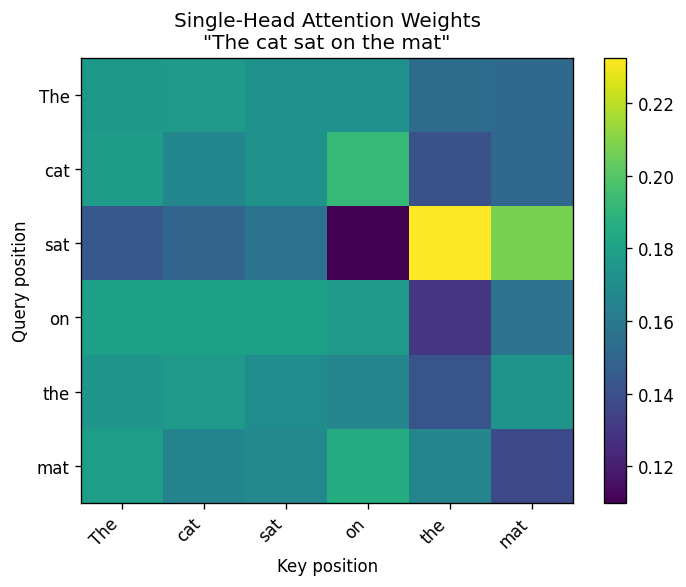

Attention weight matrix (rows=queries, cols=keys):
        The   cat   sat    on   the   mat
  The 0.175 0.176 0.172 0.172 0.153 0.152
  cat 0.177 0.167 0.172 0.192 0.140 0.151
  sat 0.144 0.150 0.157 0.110 0.232 0.207
   on 0.179 0.180 0.179 0.176 0.129 0.157
  the 0.174 0.176 0.169 0.166 0.142 0.173
  mat 0.178 0.165 0.168 0.186 0.166 0.137


In [7]:
from utils.viz import plot_attention_heatmap

# Visualize attention weights for our sample sentence
fig = plot_attention_heatmap(
    weights=np.array(attn_weights[0]),  # shape: (6, 6), remove batch dim
    tokens=tokens,
    title="Single-Head Attention Weights\n\"The cat sat on the mat\"",
)
plt.show()

# Also show the raw numbers
print("Attention weight matrix (rows=queries, cols=keys):")
print(f"{'':>5s}", end="")
for t in tokens:
    print(f"{t:>6s}", end="")
print()
for i, t in enumerate(tokens):
    print(f"{t:>5s}", end="")
    for j in range(len(tokens)):
        w = attn_weights[0, i, j].item()
        print(f"{w:6.3f}", end="")
    print()

⚠️ **Why is the attention nearly uniform?** With random (untrained) embeddings, all tokens look equally similar to each other, so attention weights are spread roughly evenly. In a **trained** model, you'd see much sharper patterns — for example, "it" would strongly attend to "cat" (its referent) and barely attend to "mat". The uniform pattern here is expected and correct for random weights.

---
## Section 3: Causal Masking

In **decoder-only** models (GPT, LLaMA, Gemma), each token can only attend to tokens at the **same or earlier** positions. This is called **causal** or **autoregressive** masking.

Why? During generation, future tokens don't exist yet. If the model could peek at future tokens during training, it would cheat — and fail at generation time.

The mask is a lower-triangular matrix:
```
1 0 0 0 0 0    ← "The" can only see itself
1 1 0 0 0 0    ← "cat" can see "The" and itself
1 1 1 0 0 0    ← "sat" can see "The", "cat", and itself
1 1 1 1 0 0    ...
1 1 1 1 1 0
1 1 1 1 1 1    ← "mat" can see everything
```

We set masked positions to $-\infty$ **before** softmax, so they become 0 after softmax.

⚠️ **Common pitfall**: Applying the mask *after* softmax doesn't work — the weights would no longer sum to 1, breaking the probability interpretation.

In [8]:
# Create a causal (lower-triangular) mask
causal_mask = mx.tril(mx.ones((seq_len, seq_len)))  # shape: (6, 6)
print("Causal mask:")
print(np.array(causal_mask).astype(int))

# Apply causal attention using our function
causal_output, causal_weights = scaled_dot_product_attention(Q, K, V, mask=causal_mask)
print(f"\nCausal output shape: {causal_output.shape}")  # (1, 6, 8)
print(f"Causal weights shape: {causal_weights.shape}")  # (1, 6, 6)

# Show the masked attention weights
print("\nCausal attention weights (upper triangle should be 0):")
w_np = np.array(causal_weights[0])
for i, t in enumerate(tokens):
    print(f"  {t:>4s}: [{', '.join(f'{w:.3f}' for w in w_np[i])}]")

# Verify rows still sum to 1
row_sums = mx.sum(causal_weights[0], axis=-1)
print(f"\nRow sums: {row_sums.tolist()}")
print("✅ Rows still sum to 1.0 even with masking")

Causal mask:
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]

Causal output shape: (1, 6, 8)
Causal weights shape: (1, 6, 6)

Causal attention weights (upper triangle should be 0):
   The: [1.000, 0.000, 0.000, 0.000, 0.000, 0.000]
   cat: [0.515, 0.485, 0.000, 0.000, 0.000, 0.000]
   sat: [0.319, 0.333, 0.348, 0.000, 0.000, 0.000]
    on: [0.251, 0.252, 0.251, 0.246, 0.000, 0.000]
   the: [0.210, 0.213, 0.205, 0.201, 0.171, 0.000]
   mat: [0.178, 0.165, 0.168, 0.186, 0.166, 0.137]

Row sums: [1.0, 1.0, 1.0, 1.0, 1.0, 0.9999999403953552]
✅ Rows still sum to 1.0 even with masking


### Visualize Causal Attention & Verify No Future Leakage

Let's plot the causal attention weights side-by-side with the unmasked version, and formally verify that no token attends to future positions.

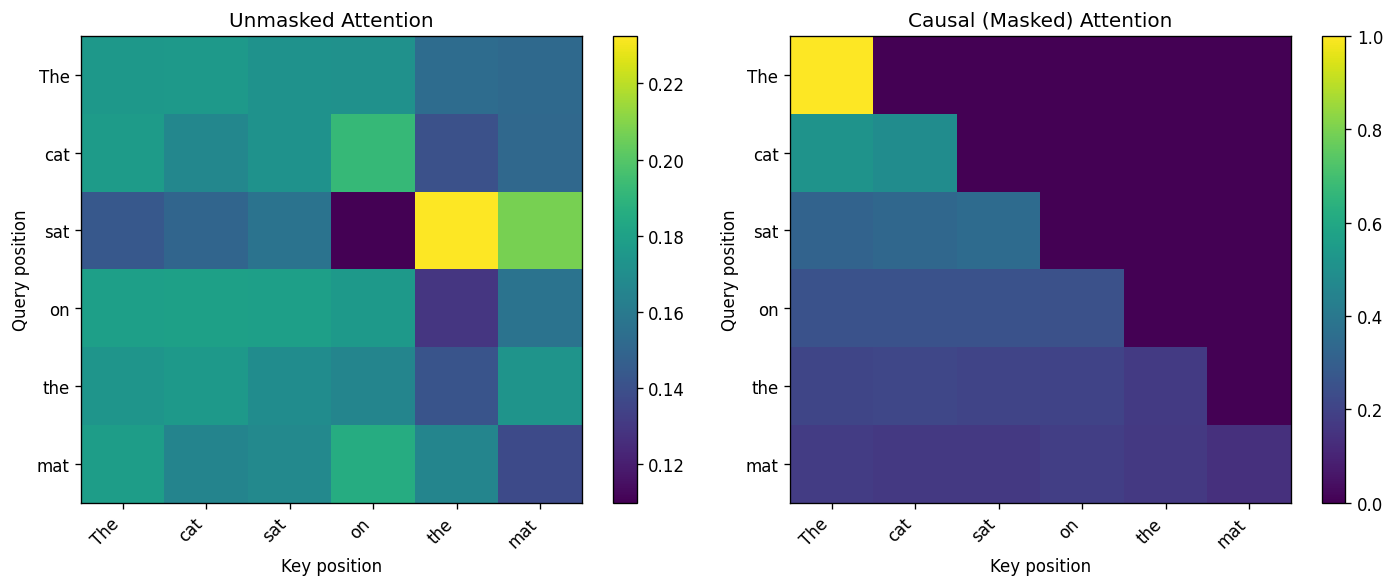

Verification: attention_weights[i][j] == 0 for all j > i
  ✅ No future information leakage detected!
  All 15 upper-triangle entries are zero.


In [9]:
# Side-by-side comparison: unmasked vs causal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_attention_heatmap(np.array(attn_weights[0]), tokens, "Unmasked Attention", ax=ax1)
plot_attention_heatmap(np.array(causal_weights[0]), tokens, "Causal (Masked) Attention", ax=ax2)

plt.tight_layout()
plt.show()

# Formal verification: no future information leakage
print("Verification: attention_weights[i][j] == 0 for all j > i")
w_np = np.array(causal_weights[0])
leaks = 0
for i in range(seq_len):
    for j in range(i + 1, seq_len):
        if abs(w_np[i, j]) > 1e-6:
            print(f"  ❌ LEAK: token {i} ({tokens[i]}) attends to future token {j} ({tokens[j]}): {w_np[i,j]:.6f}")
            leaks += 1

if leaks == 0:
    print("  ✅ No future information leakage detected!")
    print(f"  All {seq_len * (seq_len - 1) // 2} upper-triangle entries are zero.")
else:
    print(f"  ❌ Found {leaks} leaks!")

---
## Section 4: Multi-Head Attention

Single-head attention computes one set of attention weights. But a token might need to attend to different things simultaneously:
- **Syntactic head**: "sat" attends to its subject "cat"
- **Positional head**: each token attends to its neighbor
- **Semantic head**: "it" attends to its referent "cat"

**Multi-head attention** runs $h$ attention heads in parallel, each with its own Q, K, V projections, then concatenates the results.

The key insight: instead of one big attention with $d_{model}$ dimensions, we split into $h$ heads each with $d_k = d_{model} / h$ dimensions. **Same total compute, but richer attention patterns.**

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) W_O$$

where $\text{head}_i = \text{Attention}(XW_Q^i, XW_K^i, XW_V^i)$

🎯 **Interview tip**: "Why not just use a bigger single head?" — Multiple heads let the model attend to information from different representation subspaces at different positions. One head can't do this because softmax forces a single distribution.

### Step-by-Step: Splitting into Heads

Let's manually walk through how multi-head attention reshapes tensors. With `d_model=8` and `n_heads=2`, each head gets `d_k = 8/2 = 4` dimensions.

In [10]:
n_heads = 2
d_head = d_model // n_heads  # 8 // 2 = 4
batch_size = 1

print(f"d_model={d_model}, n_heads={n_heads}, d_head={d_head}")
print(f"Total params per projection: d_model × d_model = {d_model}×{d_model} = {d_model**2}")
print(f"Same as: n_heads × (d_model × d_head) = {n_heads}×({d_model}×{d_head}) = {n_heads * d_model * d_head}")

# Project to Q, K, V using a single large matrix (more efficient than per-head matrices)
W_q_mh = mx.random.normal((d_model, d_model)) * 0.1  # shape: (8, 8)
W_k_mh = mx.random.normal((d_model, d_model)) * 0.1  # shape: (8, 8)
W_v_mh = mx.random.normal((d_model, d_model)) * 0.1  # shape: (8, 8)

# Project: (1, 6, 8) @ (8, 8) → (1, 6, 8)
Q_mh = x @ W_q_mh  # shape: (1, 6, 8)
K_mh = x @ W_k_mh  # shape: (1, 6, 8)
V_mh = x @ W_v_mh  # shape: (1, 6, 8)
print(f"\nAfter projection — Q: {Q_mh.shape}, K: {K_mh.shape}, V: {V_mh.shape}")

# Reshape to split heads: (batch, seq_len, d_model) → (batch, seq_len, n_heads, d_head)
Q_heads = Q_mh.reshape(batch_size, seq_len, n_heads, d_head)  # (1, 6, 2, 4)
K_heads = K_mh.reshape(batch_size, seq_len, n_heads, d_head)  # (1, 6, 2, 4)
V_heads = V_mh.reshape(batch_size, seq_len, n_heads, d_head)  # (1, 6, 2, 4)
print(f"After reshape   — Q: {Q_heads.shape}  (batch, seq, n_heads, d_head)")

# Transpose to: (batch, n_heads, seq_len, d_head) — heads become a batch dimension
Q_heads = Q_heads.transpose(0, 2, 1, 3)  # (1, 2, 6, 4)
K_heads = K_heads.transpose(0, 2, 1, 3)  # (1, 2, 6, 4)
V_heads = V_heads.transpose(0, 2, 1, 3)  # (1, 2, 6, 4)
print(f"After transpose — Q: {Q_heads.shape}  (batch, n_heads, seq, d_head)")

# Now each head computes attention independently
# scores: (1, 2, 6, 4) @ (1, 2, 4, 6) → (1, 2, 6, 6)
scores_mh = Q_heads @ K_heads.transpose(0, 1, 3, 2) / math.sqrt(d_head)
weights_mh = mx.softmax(scores_mh, axis=-1)  # (1, 2, 6, 6)
head_outputs = weights_mh @ V_heads           # (1, 2, 6, 4)
print(f"\nPer-head scores:  {scores_mh.shape}  (batch, n_heads, seq, seq)")
print(f"Per-head weights: {weights_mh.shape}")
print(f"Per-head output:  {head_outputs.shape}  (batch, n_heads, seq, d_head)")

# Concatenate heads: transpose back and reshape
# (1, 2, 6, 4) → (1, 6, 2, 4) → (1, 6, 8)
concat = head_outputs.transpose(0, 2, 1, 3).reshape(batch_size, seq_len, d_model)
print(f"\nConcatenated: {concat.shape}  — back to (batch, seq, d_model)")

# Output projection
W_o = mx.random.normal((d_model, d_model)) * 0.1  # shape: (8, 8)
mha_output = concat @ W_o  # shape: (1, 6, 8)
print(f"Final output: {mha_output.shape}  — same shape as input ✅")

d_model=8, n_heads=2, d_head=4
Total params per projection: d_model × d_model = 8×8 = 64
Same as: n_heads × (d_model × d_head) = 2×(8×4) = 64

After projection — Q: (1, 6, 8), K: (1, 6, 8), V: (1, 6, 8)
After reshape   — Q: (1, 6, 2, 4)  (batch, seq, n_heads, d_head)
After transpose — Q: (1, 2, 6, 4)  (batch, n_heads, seq, d_head)

Per-head scores:  (1, 2, 6, 6)  (batch, n_heads, seq, seq)
Per-head weights: (1, 2, 6, 6)
Per-head output:  (1, 2, 6, 4)  (batch, n_heads, seq, d_head)

Concatenated: (1, 6, 8)  — back to (batch, seq, d_model)
Final output: (1, 6, 8)  — same shape as input ✅


### `MultiHeadAttention` as an `nn.Module`

Now let's package this into a proper MLX module with learnable parameters. This is the version you'd use in a real transformer.

⚡ Using `nn.Linear` handles weight initialization and parameter registration automatically. MLX's lazy evaluation means the projections are fused into efficient Metal kernels.

In [11]:
class MultiHeadAttention(nn.Module):
    """Multi-head self-attention with optional causal masking."""
    
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.scale = math.sqrt(self.d_head)
        
        # Single linear layer for each of Q, K, V (projects d_model → d_model)
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def __call__(self, x: mx.array, mask: mx.array | None = None) -> mx.array:
        """
        Args:
            x: (batch, seq_len, d_model)
            mask: optional (seq_len, seq_len), 0=masked, 1=attend
        Returns:
            output: (batch, seq_len, d_model)
        """
        B, T, D = x.shape
        
        # Project to Q, K, V: (B, T, D) → (B, T, D)
        Q = self.W_q(x)  # shape: (B, T, D)
        K = self.W_k(x)  # shape: (B, T, D)
        V = self.W_v(x)  # shape: (B, T, D)
        
        # Split into heads: (B, T, D) → (B, T, n_heads, d_head) → (B, n_heads, T, d_head)
        Q = Q.reshape(B, T, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        K = K.reshape(B, T, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        V = V.reshape(B, T, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        
        # Attention: (B, n_heads, T, d_head) @ (B, n_heads, d_head, T) → (B, n_heads, T, T)
        scores = (Q @ K.transpose(0, 1, 3, 2)) / self.scale
        
        if mask is not None:
            scores = mx.where(mask == 0, mx.array(float("-inf")), scores)
        
        weights = mx.softmax(scores, axis=-1)  # (B, n_heads, T, T)
        
        # Weighted sum: (B, n_heads, T, T) @ (B, n_heads, T, d_head) → (B, n_heads, T, d_head)
        out = weights @ V
        
        # Concatenate heads: (B, n_heads, T, d_head) → (B, T, D)
        out = out.transpose(0, 2, 1, 3).reshape(B, T, D)
        
        # Output projection: (B, T, D) → (B, T, D)
        return self.W_o(out)

print("MultiHeadAttention class defined ✅")

MultiHeadAttention class defined ✅


### Test the MultiHeadAttention Module

Let's verify our module works with different configurations and inspect its parameters.

In [12]:
# Test with realistic dimensions
test_d_model = 64
test_n_heads = 4
test_seq_len = 16
test_batch = 2

mha = MultiHeadAttention(d_model=test_d_model, n_heads=test_n_heads)

# Count parameters
n_params = sum(p.size for _, p in mha.parameters().items() if hasattr(p, 'size'))
# Flatten nested params for counting
def count_params(params):
    total = 0
    if isinstance(params, dict):
        for v in params.values():
            total += count_params(v)
    elif isinstance(params, (list, tuple)):
        for v in params:
            total += count_params(v)
    elif hasattr(params, 'size'):
        total += params.size
    return total

n_params = count_params(mha.parameters())
print(f"Config: d_model={test_d_model}, n_heads={test_n_heads}, d_head={test_d_model // test_n_heads}")
print(f"Total parameters: {n_params:,}")
print(f"  W_q: {test_d_model}×{test_d_model} = {test_d_model**2}")
print(f"  W_k: {test_d_model}×{test_d_model} = {test_d_model**2}")
print(f"  W_v: {test_d_model}×{test_d_model} = {test_d_model**2}")
print(f"  W_o: {test_d_model}×{test_d_model} = {test_d_model**2}")
print(f"  Total: 4 × {test_d_model}² = {4 * test_d_model**2}")

# Forward pass
test_x = mx.random.normal((test_batch, test_seq_len, test_d_model))  # (2, 16, 64)
causal = mx.tril(mx.ones((test_seq_len, test_seq_len)))  # (16, 16)

out = mha(test_x, mask=causal)  # (2, 16, 64)
mx.eval(out)

print(f"\nInput shape:  {test_x.shape}")
print(f"Output shape: {out.shape}")
assert out.shape == test_x.shape
print("✅ MultiHeadAttention forward pass works correctly")

Config: d_model=64, n_heads=4, d_head=16
Total parameters: 16,384
  W_q: 64×64 = 4096
  W_k: 64×64 = 4096
  W_v: 64×64 = 4096
  W_o: 64×64 = 4096
  Total: 4 × 64² = 16384

Input shape:  (2, 16, 64)
Output shape: (2, 16, 64)
✅ MultiHeadAttention forward pass works correctly


---
## Section 5: Grouped Query Attention (GQA)

Standard multi-head attention uses separate K, V projections for each head. This means the **KV-cache** during inference scales linearly with the number of heads — a major memory bottleneck for long sequences.

**Grouped Query Attention** (GQA) shares K and V heads across groups of query heads:

| Variant | Q heads | KV heads | Used in |
|---------|---------|----------|---------|
| **MHA** (Multi-Head) | $h$ | $h$ | GPT-2, GPT-3 |
| **MQA** (Multi-Query) | $h$ | 1 | PaLM, Falcon |
| **GQA** (Grouped Query) | $h$ | $h / g$ | LLaMA 3, Gemma 2, Mistral |

For example, LLaMA 3 8B uses 32 query heads but only 8 KV heads (group size = 4). Each group of 4 query heads shares the same K and V.

💡 **Why does this work?** Research shows that K and V representations are more redundant across heads than Q. Sharing them loses minimal quality but saves significant memory — especially for the KV-cache during inference.

⚡ **Memory savings**: With 32 heads → 8 KV heads, the KV-cache is 4× smaller. For a 128K context window, this can save tens of GB.

### Implementing GQA

The key difference from standard MHA: we project K and V to fewer heads, then **repeat** (broadcast) them to match the number of query heads before computing attention.

In [13]:
class GroupedQueryAttention(nn.Module):
    """Grouped Query Attention (GQA) — used in LLaMA 3, Gemma 2.
    
    n_kv_heads < n_heads: each KV head is shared by (n_heads // n_kv_heads) query heads.
    n_kv_heads == n_heads: equivalent to standard MHA.
    n_kv_heads == 1: equivalent to Multi-Query Attention (MQA).
    """
    
    def __init__(self, d_model: int, n_heads: int, n_kv_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        assert n_heads % n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"
        
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_groups = n_heads // n_kv_heads  # how many Q heads share each KV head
        self.d_head = d_model // n_heads
        self.scale = math.sqrt(self.d_head)
        
        # Q projects to full n_heads
        self.W_q = nn.Linear(d_model, n_heads * self.d_head, bias=False)
        # K, V project to fewer heads
        self.W_k = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.W_v = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def __call__(self, x: mx.array, mask: mx.array | None = None) -> mx.array:
        B, T, D = x.shape
        
        # Project Q to all heads, K/V to fewer heads
        Q = self.W_q(x)  # (B, T, n_heads * d_head)
        K = self.W_k(x)  # (B, T, n_kv_heads * d_head)
        V = self.W_v(x)  # (B, T, n_kv_heads * d_head)
        
        # Reshape Q: (B, T, n_heads, d_head) → (B, n_heads, T, d_head)
        Q = Q.reshape(B, T, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        
        # Reshape K, V: (B, T, n_kv_heads, d_head) → (B, n_kv_heads, T, d_head)
        K = K.reshape(B, T, self.n_kv_heads, self.d_head).transpose(0, 2, 1, 3)
        V = V.reshape(B, T, self.n_kv_heads, self.d_head).transpose(0, 2, 1, 3)
        
        # Repeat K, V to match n_heads: (B, n_kv_heads, T, d_head) → (B, n_heads, T, d_head)
        # Each KV head is repeated n_groups times
        if self.n_groups > 1:
            K = mx.repeat(K, repeats=self.n_groups, axis=1)  # (B, n_heads, T, d_head)
            V = mx.repeat(V, repeats=self.n_groups, axis=1)  # (B, n_heads, T, d_head)
        
        # Standard attention from here
        scores = (Q @ K.transpose(0, 1, 3, 2)) / self.scale  # (B, n_heads, T, T)
        
        if mask is not None:
            scores = mx.where(mask == 0, mx.array(float("-inf")), scores)
        
        weights = mx.softmax(scores, axis=-1)  # (B, n_heads, T, T)
        out = weights @ V                       # (B, n_heads, T, d_head)
        
        # Concatenate and project
        out = out.transpose(0, 2, 1, 3).reshape(B, T, D)  # (B, T, D)
        return self.W_o(out)

print("GroupedQueryAttention class defined ✅")
print(f"  n_kv_heads == n_heads  → standard MHA")
print(f"  n_kv_heads == 1        → Multi-Query Attention (MQA)")
print(f"  1 < n_kv_heads < n_heads → GQA (LLaMA 3, Gemma 2)")

GroupedQueryAttention class defined ✅
  n_kv_heads == n_heads  → standard MHA
  n_kv_heads == 1        → Multi-Query Attention (MQA)
  1 < n_kv_heads < n_heads → GQA (LLaMA 3, Gemma 2)


### Memory Comparison: MHA vs GQA

Let's compare parameter counts and KV-cache memory for standard MHA vs GQA at realistic model scales.

In [14]:
# Test GQA with LLaMA 3-like config
gqa_d_model = 64
gqa_n_heads = 8       # 8 query heads
gqa_n_kv_heads = 2    # 2 KV heads (group size = 4)

gqa = GroupedQueryAttention(gqa_d_model, gqa_n_heads, gqa_n_kv_heads)
mha_ref = MultiHeadAttention(gqa_d_model, gqa_n_heads)

# Forward pass test
test_x = mx.random.normal((1, 16, gqa_d_model))  # (1, 16, 64)
mask = mx.tril(mx.ones((16, 16)))

gqa_out = gqa(test_x, mask=mask)
mha_out = mha_ref(test_x, mask=mask)
mx.eval(gqa_out, mha_out)

print(f"GQA output shape: {gqa_out.shape}  ✅")
print(f"MHA output shape: {mha_out.shape}  ✅")
assert gqa_out.shape == mha_out.shape

# Parameter comparison
gqa_params = count_params(gqa.parameters())
mha_params = count_params(mha_ref.parameters())
print(f"\n--- Parameter Count (d_model={gqa_d_model}) ---")
print(f"MHA params: {mha_params:,}  (Q:{gqa_d_model}², K:{gqa_d_model}², V:{gqa_d_model}², O:{gqa_d_model}²)")
print(f"GQA params: {gqa_params:,}  (Q:{gqa_d_model}², K:{gqa_d_model}×{gqa_n_kv_heads * gqa_d_model // gqa_n_heads}, V:{gqa_d_model}×{gqa_n_kv_heads * gqa_d_model // gqa_n_heads}, O:{gqa_d_model}²)")
print(f"GQA saves {mha_params - gqa_params:,} params ({(1 - gqa_params/mha_params)*100:.1f}% reduction)")

# KV-cache memory comparison at scale
print(f"\n--- KV-Cache Memory (realistic scale) ---")
real_d_model = 4096
real_n_heads = 32
real_n_kv_heads = 8  # LLaMA 3 config
real_d_head = real_d_model // real_n_heads
n_layers = 32
ctx_len = 8192
bytes_per_param = 2  # float16

for label, kv_heads in [("MHA (32 KV heads)", 32), ("GQA (8 KV heads)", 8), ("MQA (1 KV head)", 1)]:
    # KV cache = 2 (K+V) × n_layers × kv_heads × ctx_len × d_head × bytes
    kv_bytes = 2 * n_layers * kv_heads * ctx_len * real_d_head * bytes_per_param
    kv_gb = kv_bytes / (1024**3)
    print(f"  {label:25s}: {kv_gb:.2f} GB")

print(f"\n🎯 GQA gives 4× KV-cache reduction with minimal quality loss!")

GQA output shape: (1, 16, 64)  ✅
MHA output shape: (1, 16, 64)  ✅

--- Parameter Count (d_model=64) ---
MHA params: 16,384  (Q:64², K:64², V:64², O:64²)
GQA params: 10,240  (Q:64², K:64×16, V:64×16, O:64²)
GQA saves 6,144 params (37.5% reduction)

--- KV-Cache Memory (realistic scale) ---
  MHA (32 KV heads)        : 4.00 GB
  GQA (8 KV heads)         : 1.00 GB
  MQA (1 KV head)          : 0.12 GB

🎯 GQA gives 4× KV-cache reduction with minimal quality loss!


### Visualize: MHA vs GQA Head Structure

Let's visualize how query heads map to KV heads in each attention variant.

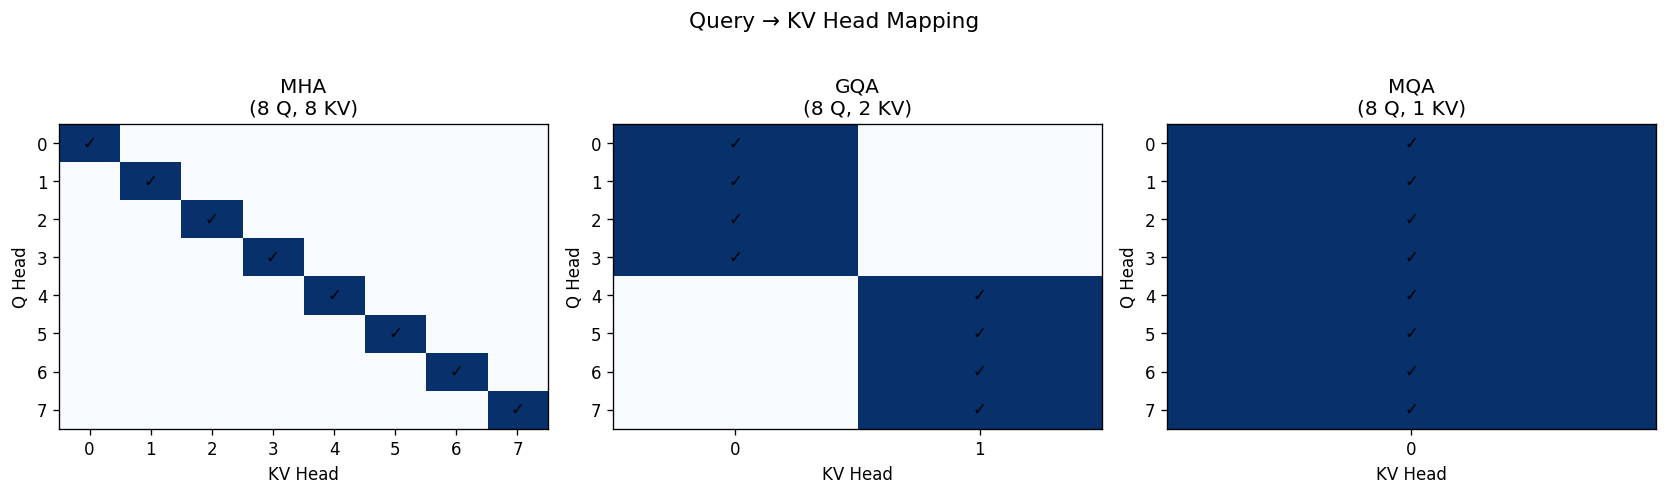

Left: Standard MHA — each Q head has its own KV head (1:1)
Middle: GQA — groups of 4 Q heads share one KV head (4:1)
Right: MQA — all Q heads share a single KV head (8:1)


In [15]:
# Visualize the head-sharing patterns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    ("MHA\n(8 Q, 8 KV)", 8, 8),
    ("GQA\n(8 Q, 2 KV)", 8, 2),
    ("MQA\n(8 Q, 1 KV)", 8, 1),
]

for ax, (title, nq, nkv) in zip(axes, configs):
    # Create a mapping matrix: which Q head uses which KV head
    mapping = np.zeros((nq, nkv))
    group_size = nq // nkv
    for q in range(nq):
        kv = q // group_size
        mapping[q, kv] = 1.0
    
    ax.imshow(mapping, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xlabel("KV Head")
    ax.set_ylabel("Q Head")
    ax.set_title(title)
    ax.set_xticks(range(nkv))
    ax.set_yticks(range(nq))
    
    # Add text annotations
    for i in range(nq):
        for j in range(nkv):
            if mapping[i, j] > 0:
                ax.text(j, i, "✓", ha="center", va="center", fontsize=10)

plt.suptitle("Query → KV Head Mapping", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Left: Standard MHA — each Q head has its own KV head (1:1)")
print("Middle: GQA — groups of 4 Q heads share one KV head (4:1)")
print("Right: MQA — all Q heads share a single KV head (8:1)")

---
## Summary & Key Takeaways

### What We Built
1. **Single-head attention** from raw matrix operations: Q, K, V projections → scores → scale → softmax → weighted sum
2. **Attention visualization** showing which tokens attend to which
3. **Causal masking** to prevent future information leakage in decoder models
4. **Multi-head attention** (`MultiHeadAttention`) as a reusable `nn.Module`
5. **Grouped Query Attention** (`GroupedQueryAttention`) for memory-efficient inference

### Key Formulas

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

### 🎯 Interview Cheat Sheet
- **Why scale by $\sqrt{d_k}$?** — Prevents softmax saturation; keeps gradient flow healthy
- **Why multiple heads?** — Each head can learn different attention patterns (syntactic, semantic, positional)
- **Why causal mask?** — Decoder models can't see future tokens during generation
- **Why GQA over MHA?** — 4× KV-cache reduction with <1% quality loss; critical for long-context inference
- **MHA vs MQA vs GQA?** — MQA is too aggressive (quality loss), MHA is too expensive (memory), GQA is the sweet spot

### ⚡ Apple Silicon Notes
- All attention operations are matrix multiplications → excellent Metal GPU utilization
- Unified memory means KV-cache doesn't need CPU↔GPU transfers
- GQA is especially important on 48GB machines for fitting long contexts

### Next Up
**Notebook 06: Transformer Architecture** — We'll combine attention with feed-forward networks, layer normalization, and residual connections to build a complete transformer block.

---
## 🕰️ Deep Dive: The Chronological Evolution of Attention

This section traces the evolution of attention mechanisms from 2017 to 2025, explaining **what problem each innovation solved**, **why it was better than alternatives**, and **implementing each variant in MLX**.

### Timeline of Attention Innovations

| Year | Innovation | Paper | Problem Solved |
|------|-----------|-------|---------------|
| 2017 | **Scaled Dot-Product Attention** | "Attention Is All You Need" | Replaced recurrence with parallelizable attention |
| 2017 | **Multi-Head Attention (MHA)** | Same paper | Single head can't capture diverse patterns |
| 2019 | **Multi-Query Attention (MQA)** | Shazeer, "Fast Transformer Decoding" | KV-cache too large for inference |
| 2022 | **Flash Attention** | Dao et al. | O(n²) memory for attention matrix |
| 2023 | **Grouped Query Attention (GQA)** | Ainslie et al. (Google) | MQA too aggressive, MHA too expensive |
| 2023 | **Sliding Window Attention** | Mistral AI | Full attention unnecessary for local patterns |
| 2024 | **Interleaved Local/Global** | Gemma 2/3 | Balance local efficiency with global context |
| 2025 | **K=V Sharing + p-RoPE** | Gemma 4 | Further reduce KV-cache; better long-context |

💡 **Key insight**: Each innovation addresses a specific bottleneck. Understanding the bottleneck helps you understand why the solution works.

### 🔬 Why Attention Replaced Recurrence (2017)

**The Problem with RNNs/LSTMs:**
- Process tokens **sequentially** — can't parallelize across sequence length
- Information from early tokens must pass through every intermediate step → **vanishing gradients**
- Training time scales linearly with sequence length (can't use GPU parallelism)

**What Attention Solved:**
- Every token can directly attend to every other token — **O(1) path length**
- All attention computations happen in parallel — **GPU-friendly**
- No information bottleneck — each token gets a fresh, weighted view of the entire sequence

**The Tradeoff:**
- Attention is O(n²) in memory and compute (vs O(n) for RNNs)
- For very long sequences, this becomes the bottleneck → motivates Flash Attention, sliding window, etc.

⚠️ **Common misconception**: "Attention replaced RNNs because it's more powerful." Not exactly — attention replaced RNNs because it's **more parallelizable**. The power comes from the combination of attention + scale (more data, more parameters).

In [ ]:
# Interactive comparison: RNN vs Attention path lengths
# This demonstrates WHY attention is better for long-range dependencies

import mlx.core as mx
import numpy as np
import matplotlib.pyplot as plt

seq_lengths = [8, 16, 32, 64, 128, 256, 512, 1024]

# RNN: information from token 0 must pass through ALL intermediate tokens to reach token N
# Path length = N (linear)
rnn_path = seq_lengths  # O(n)

# Attention: token 0 directly attends to token N
# Path length = 1 (constant)
attn_path = [1] * len(seq_lengths)  # O(1)

# Compute: RNN is O(n), Attention is O(n²)
rnn_compute = seq_lengths  # O(n)
attn_compute = [n**2 for n in seq_lengths]  # O(n²)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Path length (attention wins)
ax1.plot(seq_lengths, rnn_path, 'r-o', label='RNN/LSTM', linewidth=2)
ax1.plot(seq_lengths, attn_path, 'b-o', label='Attention', linewidth=2)
ax1.set_xlabel('Sequence Length')
ax1.set_ylabel('Max Path Length')
ax1.set_title('Information Path Length\n(Lower = Better for Learning)')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Right: Compute cost (RNN wins for very long sequences)
ax2.plot(seq_lengths, rnn_compute, 'r-o', label='RNN: O(n)', linewidth=2)
ax2.plot(seq_lengths, attn_compute, 'b-o', label='Attention: O(n²)', linewidth=2)
ax2.set_xlabel('Sequence Length')
ax2.set_ylabel('Compute (relative)')
ax2.set_title('Compute Cost\n(Lower = Faster)')
ax2.legend()
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Attention wins on path length (better gradients) but loses on compute for long sequences.")
print("   This tradeoff motivates ALL subsequent attention innovations:")
print("   Flash Attention → reduce memory")
print("   Sliding Window → reduce compute for local patterns")
print("   GQA → reduce KV-cache memory")
print("   K=V Sharing → further reduce memory (Gemma 4)")

### 🔬 MHA vs MQA vs GQA: The KV-Cache Problem

**The Problem (discovered during deployment, not training):**

During autoregressive generation, we cache K and V from all previous tokens (the "KV-cache"). For standard MHA with 32 heads:
- KV-cache per token = 2 × 32 × d_head × bytes_per_param
- For a 7B model with 128K context: **~32 GB** just for KV-cache!

This is the #1 memory bottleneck for long-context inference.

**Three solutions, in chronological order:**

1. **MQA (2019)**: All query heads share ONE KV head → 32× reduction
   - ❌ Too aggressive — quality drops noticeably
   
2. **GQA (2023)**: Groups of query heads share KV heads → 4-8× reduction
   - ✅ Sweet spot — <1% quality loss with 4× memory savings
   - Used in: LLaMA 2/3, Gemma 2, Mistral

3. **K=V Sharing (2025, Gemma 4)**: K and V are the SAME tensor → additional 2× reduction
   - ✅ Further savings with minimal quality impact
   - Combined with GQA for maximum efficiency

In [ ]:
# Interactive: KV-cache memory comparison across all attention variants
# This is the KEY insight for understanding why GQA and K=V sharing matter

import mlx.core as mx
import matplotlib.pyplot as plt
import numpy as np

def kv_cache_memory_gb(
    n_layers, n_kv_heads, d_head, seq_len, 
    bytes_per_param=2,  # float16
    kv_shared=False     # Gemma 4's K=V sharing
):
    """Calculate KV-cache memory in GB."""
    # 2 for K+V (or 1 if K=V shared)
    kv_factor = 1 if kv_shared else 2
    return kv_factor * n_layers * n_kv_heads * seq_len * d_head * bytes_per_param / 1e9

# LLaMA 3 8B-like config
n_layers = 32
d_head = 128
n_query_heads = 32

context_lengths = [2048, 4096, 8192, 16384, 32768, 65536, 131072]

variants = {
    'MHA (32 KV heads)':     {'n_kv': 32, 'kv_shared': False, 'color': 'red'},
    'GQA (8 KV heads)':      {'n_kv': 8,  'kv_shared': False, 'color': 'orange'},
    'MQA (1 KV head)':       {'n_kv': 1,  'kv_shared': False, 'color': 'green'},
    'GQA + K=V (Gemma 4)':   {'n_kv': 8,  'kv_shared': True,  'color': 'blue'},
}

fig, ax = plt.subplots(figsize=(10, 5))

for label, cfg in variants.items():
    mem = [kv_cache_memory_gb(n_layers, cfg['n_kv'], d_head, ctx, kv_shared=cfg['kv_shared']) 
           for ctx in context_lengths]
    ax.plot(context_lengths, mem, '-o', label=label, color=cfg['color'], linewidth=2)

# Add 48GB and 20GB budget lines
ax.axhline(y=44, color='gray', linestyle='--', alpha=0.5, label='48GB Mac budget (44GB usable)')
ax.axhline(y=20, color='gray', linestyle=':', alpha=0.5, label='20GB budget limit')

ax.set_xlabel('Context Length (tokens)')
ax.set_ylabel('KV-Cache Memory (GB)')
ax.set_title('KV-Cache Memory vs Context Length\n(32-layer model, d_head=128, float16)')
ax.legend(fontsize=8)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50)

plt.tight_layout()
plt.show()

# Print exact numbers for 128K context
print("\nKV-Cache at 128K context (32 layers, d_head=128, float16):")
print(f"{'Variant':<25} {'Memory':>10} {'vs MHA':>10}")
print("-" * 48)
for label, cfg in variants.items():
    mem = kv_cache_memory_gb(n_layers, cfg['n_kv'], d_head, 131072, kv_shared=cfg['kv_shared'])
    mha_mem = kv_cache_memory_gb(n_layers, 32, d_head, 131072)
    print(f"{label:<25} {mem:>8.1f} GB {mem/mha_mem:>9.1%}")

print("\n🎯 GQA + K=V sharing (Gemma 4) uses only 6.25% of MHA's KV-cache memory!")
print("   This is what enables 128K+ context on a 48GB Mac.")

### 🔬 Gemma 4's Attention Innovations (2025 SOTA)

Gemma 4 introduces three key attention innovations:

#### 1. Interleaved Local/Global Attention
Instead of using the same attention pattern for every layer, Gemma 4 **alternates**:
- **Local layers** (sliding window, W=512 or 1024): Cheap, captures nearby context
- **Global layers** (full attention): Expensive, captures long-range dependencies
- Pattern: local → local → ... → global → local → ... → global (last layer is always global)

**Why this works**: Most information in language is local (nearby words matter most). Only a few layers need global context. This saves ~50% of attention compute.

#### 2. K=V Sharing in Global Attention
In global attention layers, K and V are the **same tensor**. This halves the KV-cache for global layers.

**Why this works**: Research shows K and V representations are highly correlated in practice. Sharing them loses minimal information.

#### 3. p-RoPE (Proportional RoPE)
Standard RoPE uses the same frequency base for all layers. Gemma 4 uses **p-RoPE** with p=0.25 for global attention layers:
- Scales the RoPE frequencies by a factor of 0.25
- Preserves low-frequency (long-range) positional information
- Enables better extrapolation to longer contexts

💡 **Why p=0.25?** Lower frequencies capture longer-range position relationships. By scaling down, the model can "see" further without the high-frequency noise that hurts extrapolation.

In [ ]:
# Implement Gemma 4's interleaved local/global attention pattern

import mlx.core as mx
import mlx.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

class Gemma4Attention(nn.Module):
    """Gemma 4-style attention with interleaved local/global layers.
    
    Innovations:
    1. Alternating sliding window (local) and full (global) attention
    2. K=V sharing in global attention layers
    3. p-RoPE for global layers (proportional frequency scaling)
    4. Logit soft-capping for stability
    """
    
    def __init__(self, d_model: int, n_heads: int, n_kv_heads: int, 
                 is_global: bool = False, window_size: int = 512,
                 rope_p: float = 0.25, softcap: float = 50.0):
        super().__init__()
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.d_head = d_model // n_heads
        self.scale = math.sqrt(self.d_head)
        self.is_global = is_global
        self.window_size = window_size
        self.rope_p = rope_p
        self.softcap = softcap
        self.n_groups = n_heads // n_kv_heads
        
        # Q always projects to full n_heads
        self.W_q = nn.Linear(d_model, n_heads * self.d_head, bias=False)
        
        if is_global:
            # K=V sharing: single projection for both K and V
            self.W_kv = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        else:
            # Standard separate K, V projections for local attention
            self.W_k = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
            self.W_v = nn.Linear(d_model, n_kv_heads * self.d_head, bias=False)
        
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def __call__(self, x: mx.array, mask: mx.array = None) -> mx.array:
        B, T, D = x.shape
        
        # Project Q
        Q = self.W_q(x).reshape(B, T, self.n_heads, self.d_head).transpose(0, 2, 1, 3)
        
        if self.is_global:
            # K=V sharing: same tensor for both K and V
            KV = self.W_kv(x).reshape(B, T, self.n_kv_heads, self.d_head).transpose(0, 2, 1, 3)
            K = KV  # K and V are the SAME tensor
            V = KV
        else:
            K = self.W_k(x).reshape(B, T, self.n_kv_heads, self.d_head).transpose(0, 2, 1, 3)
            V = self.W_v(x).reshape(B, T, self.n_kv_heads, self.d_head).transpose(0, 2, 1, 3)
        
        # Repeat KV heads for GQA
        if self.n_groups > 1:
            K = mx.repeat(K, repeats=self.n_groups, axis=1)
            V = mx.repeat(V, repeats=self.n_groups, axis=1)
        
        # Compute attention scores
        scores = (Q @ K.transpose(0, 1, 3, 2)) / self.scale
        
        # Logit soft-capping (Gemma 4 innovation for stability)
        if self.is_global and self.softcap > 0:
            scores = mx.tanh(scores / self.softcap) * self.softcap
        
        # Apply mask (causal + optional sliding window)
        if mask is not None:
            scores = mx.where(mask == 0, mx.array(float('-inf')), scores)
        
        weights = mx.softmax(scores, axis=-1)
        out = (weights @ V).transpose(0, 2, 1, 3).reshape(B, T, D)
        return self.W_o(out)


def create_gemma4_mask(seq_len: int, is_global: bool, window_size: int = 512) -> mx.array:
    """Create attention mask for Gemma 4.
    
    Global layers: standard causal mask (full attention)
    Local layers: sliding window causal mask
    """
    if is_global:
        return mx.tril(mx.ones((seq_len, seq_len)))
    else:
        # Sliding window: each token attends to at most window_size previous tokens
        mask = mx.zeros((seq_len, seq_len))
        for i in range(seq_len):
            start = max(0, i - window_size + 1)
            for j in range(start, i + 1):
                mask = mask.at[i, j].add(1.0)
        mx.eval(mask)
        return mask


# Demo: Compare local vs global attention
seq_len = 32
d_model = 64
n_heads = 4
n_kv_heads = 2

# Local attention (sliding window)
local_attn = Gemma4Attention(d_model, n_heads, n_kv_heads, is_global=False, window_size=8)
local_mask = create_gemma4_mask(seq_len, is_global=False, window_size=8)

# Global attention (full, with K=V sharing)
global_attn = Gemma4Attention(d_model, n_heads, n_kv_heads, is_global=True)
global_mask = create_gemma4_mask(seq_len, is_global=True)

x = mx.random.normal((1, seq_len, d_model))
local_out = local_attn(x, local_mask)
global_out = global_attn(x, global_mask)
mx.eval(local_out, global_out)

print("Gemma 4 Attention Variants:")
print(f"  Local (sliding window W=8):  output shape = {local_out.shape}")
print(f"  Global (full, K=V shared):   output shape = {global_out.shape}")
print(f"  K=V sharing saves: {n_kv_heads * d_model // n_heads * 2 / 1024:.1f} KB per token per layer")

# Visualize the two mask patterns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(np.array(local_mask), cmap='Blues', aspect='auto')
ax1.set_title('Local Attention Mask\n(Sliding Window W=8)')
ax1.set_xlabel('Key position')
ax1.set_ylabel('Query position')

ax2.imshow(np.array(global_mask), cmap='Blues', aspect='auto')
ax2.set_title('Global Attention Mask\n(Full Causal)')
ax2.set_xlabel('Key position')
ax2.set_ylabel('Query position')

plt.suptitle('Gemma 4: Interleaved Local/Global Attention Patterns', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 Gemma 4 alternates these patterns across layers:")
print("   Layer 0: Local → Layer 1: Local → ... → Layer N-1: Global")
print("   The last layer is ALWAYS global (ensures full context access)")
print("   This saves ~50% of attention compute vs all-global")

### 🔬 Why Each Innovation Matters: A Decision Tree

When designing an attention mechanism for your LLM, here's how to think about the choices:

```
Start: How long is your context?
│
├── Short (≤4K tokens)
│   └── Standard MHA is fine
│       └── Memory is not a bottleneck
│
├── Medium (4K-32K tokens)
│   └── Use GQA (4-8 KV heads)
│       └── Saves 4-8× KV-cache memory
│       └── <1% quality loss
│
└── Long (32K-256K+ tokens)
    ├── Use GQA + Sliding Window (Mistral style)
    │   └── Local layers: O(n×W) instead of O(n²)
    │   └── Global layers: full attention for long-range
    │
    └── Use GQA + K=V Sharing + p-RoPE (Gemma 4 style)
        └── Maximum memory efficiency
        └── Best extrapolation to unseen lengths
        └── Current SOTA for open models
```

⚡ **Apple Silicon note**: On a 48GB Mac, GQA + sliding window lets you run 128K context with a 7B model. Without these optimizations, you'd be limited to ~8K context.

🎯 **Interview answer**: "The evolution of attention is driven by the memory-bandwidth bottleneck during inference. Each innovation — MQA, GQA, Flash Attention, sliding window, K=V sharing — addresses a specific aspect of this bottleneck while preserving model quality."

---
## ➡️ What's Next?

You've completed this notebook! In **Notebook 06: Transformer Architecture**, we'll explore assembling attention, FFN, and norms into a full block.

💡 **Before moving on**, make sure you can answer these questions:
- What was the main concept in this notebook?
- Why does it matter for building LLMs?
- Could you explain it to a friend in one sentence?

## 📜 History & Alternatives

### The Evolution of Attention Mechanisms

Attention is the core innovation that made transformers possible. The journey from fixed-context RNNs to efficient multi-query attention spans a decade of breakthroughs.

| Year | Innovation | Team | Key Contribution |
|------|-----------|------|-----------------|
| 2014 | **Bahdanau Attention** | Bahdanau, Cho, Bengio | First attention mechanism — learned alignment for seq2seq, additive scoring |
| 2015 | **Luong Attention** | Luong, Pham, Manning | Simplified attention with dot-product scoring — faster than Bahdanau |
| 2017 | **Scaled Dot-Product Attention** | Vaswani et al. (Google) | Multi-head self-attention with √d_k scaling — the Transformer |
| 2019 | **Multi-Head Attention (MHA)** | (standard Transformer) | Parallel attention heads capture different relationship types |
| 2019 | **Multi-Query Attention (MQA)** | Shazeer (Google) | Single KV head shared across all query heads — 8× smaller KV cache |
| 2019 | **Sparse Attention** | Child et al. (OpenAI) | Attend to fixed sparse patterns — O(n√n) instead of O(n²) |
| 2020 | **Linear Attention** | Katharopoulos et al. | Kernel trick to avoid materializing attention matrix — O(n) but lower quality |
| 2022 | **Flash Attention** | Dao et al. (Stanford) | IO-aware tiled attention — exact O(n²) computation with O(n) memory |
| 2023 | **Grouped-Query Attention (GQA)** | Ainslie et al. (Google) | Groups of query heads share KV heads — balance between MHA and MQA |
| 2023 | **Flash Attention 2** | Dao (Stanford) | 2× faster than FA1 — better work partitioning, reduced non-matmul FLOPs |
| 2023 | **Paged Attention** | Kwon et al. (UC Berkeley) | Virtual memory for KV cache — enables efficient batched serving (vLLM) |
| 2024 | **Flash Attention 3** | Dao et al. | Hopper GPU optimizations — FP8, warp specialization, asynchronous execution |
| 2024 | **Ring Attention** | Liu et al. (UC Berkeley) | Distributed attention across devices — enables near-infinite context |
| 2024 | **Differential Attention** | Ye et al. (Microsoft) | Two softmax maps subtracted — reduces attention noise |

### 💡 The Attention Efficiency Spectrum

```
Quality ←————————————————————————→ Speed
  MHA        GQA        MQA      Linear Attention
(best)    (balanced)  (fast)     (fastest, lower quality)
```

Modern LLMs converge on **GQA** as the sweet spot:
- LLaMA 2 70B, LLaMA 3, Mistral, Gemma 2/3/4 all use GQA
- Typically 8 KV heads for 32 query heads (4:1 ratio)

### KV Cache Memory Comparison

| Method | KV Cache Size (per layer) | Used By |
|--------|--------------------------|---------|
| MHA | 2 × n_heads × seq_len × d_head | GPT-2, GPT-3 |
| GQA (4:1) | 2 × (n_heads/4) × seq_len × d_head | LLaMA 3, Gemma, Mistral |
| MQA | 2 × 1 × seq_len × d_head | PaLM, Gemini 1.0 |

### ⚡ Performance Impact

Flash Attention doesn't change the O(n²) compute complexity — it changes the memory access pattern. By tiling Q, K, V into SRAM-sized blocks and using online softmax, it reduces HBM reads from O(n²) to O(n), making attention 2-4× faster in practice. This is why every modern LLM training run uses Flash Attention.

### ⚠️ Common Pitfalls

- **Confusing MQA and GQA**: MQA uses a *single* KV head for all query heads; GQA uses *groups* of KV heads. MQA is a special case of GQA where `n_kv_heads = 1`. Mixing these up in interviews is a red flag.
- **Assuming Flash Attention changes the result**: Flash Attention computes *exact* attention — it's an IO optimization, not an approximation. The output is mathematically identical (within float tolerance) to standard attention.
- **Forgetting the √d_k scaling**: Without scaling, dot-product scores grow with dimension, pushing softmax into saturation where gradients vanish. This is why Bahdanau used additive scoring — dot-product only became practical after Vaswani added the scaling factor.
- **Ignoring KV-cache growth at inference**: Attention memory during *training* is dominated by the O(n²) attention matrix, but during *inference* the KV cache grows linearly with sequence length per layer. For long-context models (128K+ tokens), KV cache can exceed model weights in memory.

### 🎯 Interview Tip

> *"The key insight of self-attention is that it computes all-pairs interactions in O(1) sequential steps (vs O(n) for RNNs), but at O(n²) compute cost. The evolution since 2017 has been about reducing this cost: sparse attention reduces the number of pairs, linear attention approximates the softmax kernel, and Flash Attention keeps exact computation but optimizes memory access. GQA reduces the KV cache (memory) without approximating attention quality — it's an orthogonal optimization. In practice, GQA + Flash Attention is the standard combination in 2024-2025 LLMs."*